**Nama: Richie Darrian Prayogo**  
**NIM: 2802408133**

# Video Penjelasan

Link: https://www.youtube.com/watch?v=MPKklpeHd7A&list=PLOh0HbCqILkw&index=3

# Nomor 3 - Generative Adversial Network (GAN)
Dataset yang digunakan: **Stadium** dan **Oil Gas Field** - Dataset (NIM Ganjil, Laki-laki)

### Pemuatan Library

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.legacy import Adam as AdamLegacy

import scipy
from scipy import linalg

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

2026-06-28 18:50:11.993139: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782672612.240898      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782672612.309423      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782672612.847553      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782672612.847608      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782672612.847612      23 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


### **a. [LO 1, LO 2, LO 3, 5 poin] Jelaskan cara kerja dari arsitektur tersebut yang dideskripsikan dalam gambar di bawah ini:**
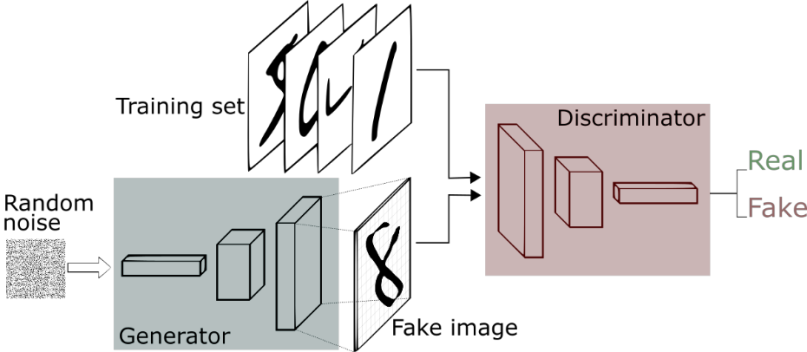

- **Generative Adversarial Network (GAN)** merupakan arsitektur *deep learning* yang terdiri dari dua neural networks yang dilatih secara bersamaan melalui proses **adversarial training**, yaitu mekanisme kompetitif di mana kedua jaringan saling meningkatkan kemampuannya.

- **Generator (G)** bertugas menghasilkan **data sintetis (*fake images*)**.
  - Menerima input berupa **random noise** yang berasal dari distribusi normal atau uniform.
  - Mengubah *random noise* menjadi gambar melalui serangkaian layer jaringan saraf.
  - Bertujuan menghasilkan gambar yang semirip mungkin dengan gambar asli sehingga **Discriminator menganggapnya sebagai gambar nyata**.

- **Discriminator (D)** bertugas membedakan gambar asli dan gambar sintetis.
  - Menerima dua jenis input:
    - Gambar asli dari *training set* (**label = 1**).
    - Gambar sintetis dari Generator (**label = 0**).
  - Menghasilkan probabilitas bahwa suatu gambar merupakan gambar asli.
  - Bertujuan mengklasifikasikan gambar asli dan gambar palsu secara benar.

- **Proses pelatihan** dilakukan secara bergantian.
  1. **Melatih Discriminator**
     - Diberikan *batch* gambar asli dan gambar sintetis dari Generator.
     - Bobot Discriminator diperbarui agar semakin akurat membedakan keduanya.
  2. **Melatih Generator**
     - Bobot Discriminator dibekukan (*freeze*).
     - Generator menerima sinyal *gradient* dari Discriminator.
     - Bobot Generator diperbarui agar menghasilkan gambar yang semakin sulit dibedakan dari gambar asli.
  3. Langkah tersebut diulang hingga Generator dan Discriminator sama-sama mencapai performa terbaiknya.

- **Kondisi ideal pelatihan** adalah **Nash Equilibrium**, yaitu ketika gambar yang dihasilkan Generator sudah sangat menyerupai gambar asli sehingga Discriminator hanya mampu menebak apakah gambar tersebut asli atau palsu dengan probabilitas sekitar **50%**.

- **Fungsi loss** yang digunakan bersifat saling berlawanan.
  - **Discriminator Loss**
    - Menggunakan **Binary Cross-Entropy (BCE)**.
    - Bertujuan mengklasifikasikan:
      - Gambar asli -> **1**
      - Gambar sintetis -> **0**
    - Persamaan:
      ```text
      Loss_D = BCE(D(x_real), 1) + BCE(D(G(z)), 0)
      ```
  - **Generator Loss**
    - Menggunakan **Binary Cross-Entropy (BCE)**.
    - Bertujuan membuat Discriminator menganggap gambar sintetis sebagai gambar asli (**target = 1**).
    - Persamaan:
      ```text
      Loss_G = BCE(D(G(z)), 1)
      ```

- **Evaluasi kualitas GAN** tidak hanya berdasarkan nilai *loss* karena nilai *loss* tidak selalu mencerminkan kualitas visual gambar yang dihasilkan.

- **Fréchet Inception Distance (FID)** digunakan untuk mengevaluasi kualitas hasil Generator.
  - Mengukur jarak statistik antara distribusi gambar asli dan gambar sintetis menggunakan representasi fitur dari model **InceptionV3**.
  - **Semakin kecil nilai FID**, semakin mirip distribusi gambar sintetis dengan gambar asli sehingga kualitas dan keragaman gambar yang dihasilkan semakin baik.

### **b. [LO 3, LO 4, 10 poin] Buatlah arsitektur untuk image generation sesuai dengan gambar arsitektur GAN berikut ini. Lakukan evaluasi kesamaan distribusi citra dengan menggunakan Fréchet Inception Distance (FID) pada data test.**


### Pemuatan Data

Dataset yang digunakan adalah **Stadium** dan **Oil Gas Field** dari Overhead-MNIST (dua kelas citra aerial 28×28 piksel dalam skala grayscale). Data dimuat dari kedua split (train dan test) yang sudah disediakan oleh Kaggle, kemudian digabungkan menjadi satu pool sebelum dilakukan pembagian ulang secara terkontrol. Penggabungan ini dilakukan karena GAN tidak memerlukan label selama inference, ia hanya perlu melihat sebanyak mungkin variasi gambar nyata selama training agar distribusinya dapat dimodelkan dengan baik.

In [ ]:
BASE_DIR = '/kaggle/input/datasets/datamunge/overheadmnist/version2'
TARGET_CLASSES = ['stadium', 'oil_gas_field']

TRAIN_DIR = os.path.join(BASE_DIR, 'train')
TEST_DIR = os.path.join(BASE_DIR, 'test')

def load_images_from_dir(train_dir, test_dir, class_name, label):
    images, labels = [], []
    for folder_path in [os.path.join(train_dir, class_name),
                        os.path.join(test_dir,  class_name)]:
        if not os.path.exists(folder_path):
            continue
        for fname in sorted(os.listdir(folder_path)):
            if fname.lower().endswith(('.jpg', '.png', '.jpeg')):
                img = Image.open(os.path.join(folder_path, fname)).convert('L')
                img = img.resize((28, 28))
                images.append(np.array(img))
                labels.append(label)
    return np.array(images), np.array(labels)

X_stadium, y_stadium = load_images_from_dir(TRAIN_DIR, TEST_DIR, 'stadium', 0)
X_oil, y_oil = load_images_from_dir(TRAIN_DIR, TEST_DIR, 'oil_gas_field', 1)

X_all = np.concatenate([X_stadium, X_oil], axis=0)
y_all = np.concatenate([y_stadium, y_oil], axis=0)

print(f"Total gambar : {X_all.shape[0]}")
print(f"Shape        : {X_all.shape[1:]}")

Total gambar : 15589
Shape        : (28, 28)


### Prapemrosesan Awal

Pada tahap prapemrosesan, seluruh nilai piksel gambar terlebih dahulu dikonversi ke tipe data float32 dan dinormalisasi ke rentang [-1, 1] agar sesuai dengan fungsi aktivasi tanh pada output Generator sehingga proses pelatihan menjadi lebih stabil. Selanjutnya, data diubah ke bentuk (N, 28, 28, 1) agar sesuai dengan format input yang dibutuhkan oleh layer konvolusi pada arsitektur GAN dengan dimensi terakhir merepresentasikan satu kanal citra grayscale. Setelah itu, dataset dibagi menggunakan stratified split menjadi 80% data pelatihan, 10% data validasi, dan 10% data pengujian untuk mempertahankan proporsi masing-masing kelas pada setiap subset sehingga distribusi kelas tetap seimbang selama proses pelatihan dan evaluasi.

Nilai piksel setelah normalisasi: min=-1.00, max=1.00
Train : 12471 | Val : 1559 | Test : 1559


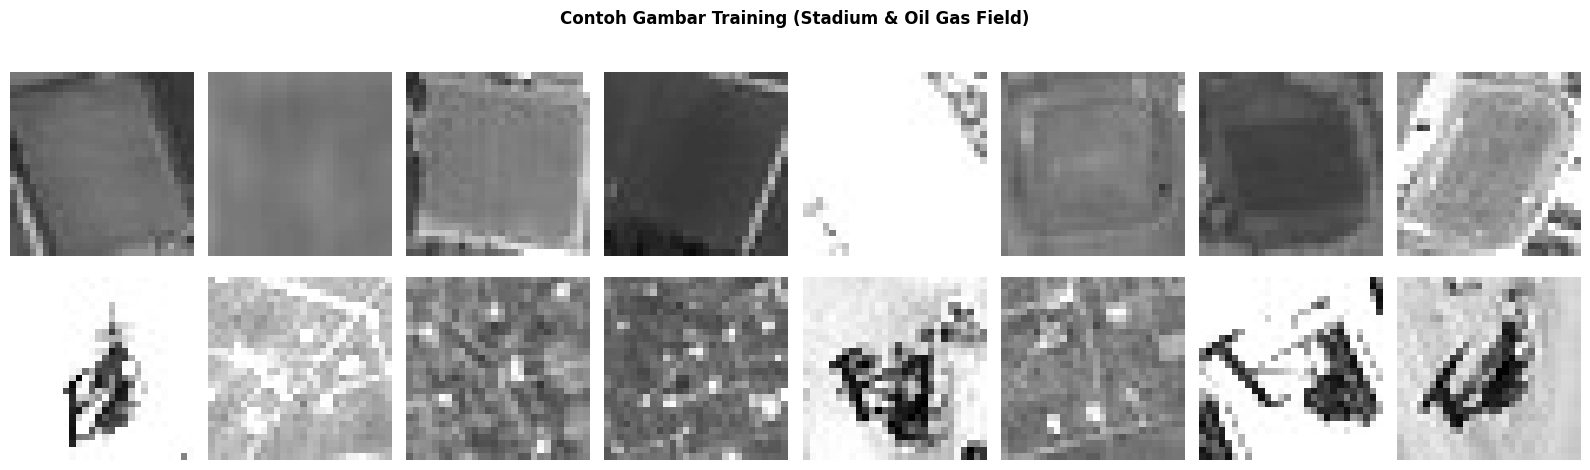

In [ ]:
# Normalisasi ke [-1, 1] untuk GAN (cocok dengan tanh pada output Generator)
X_norm = X_all.astype('float32') / 127.5 - 1.0

print(f"Nilai piksel setelah normalisasi: min={X_norm.min():.2f}, max={X_norm.max():.2f}")

# Reshape ke (N, 28, 28, 1)
X_gan = X_norm.reshape(-1, 28, 28, 1)

# Split: 80% train, 10% val, 10% test
X_train_g, X_temp, y_train_g, y_temp = train_test_split(X_gan, y_all, test_size=0.2, random_state=SEED, stratify=y_all)
X_val_g, X_test_g, y_val_g, y_test_g = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)

print(f"Train : {X_train_g.shape[0]} | Val : {X_val_g.shape[0]} | Test : {X_test_g.shape[0]}")

# Tampilkan contoh data
class_names = {0: 'Stadium', 1: 'Oil Gas Field'}
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('Contoh Gambar Training (Stadium & Oil Gas Field)', fontsize=12, fontweight='bold')
for i, class_id in enumerate([0, 1]):
    idx = np.where(y_train_g == class_id)[0][:8]
    for j, ix in enumerate(idx):
        ax = axes[i, j]
        ax.imshow((X_train_g[ix, :, :, 0] + 1) / 2, cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        if j == 0:
            ax.set_ylabel(class_names[class_id], fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

### Arsitektur Baseline GAN
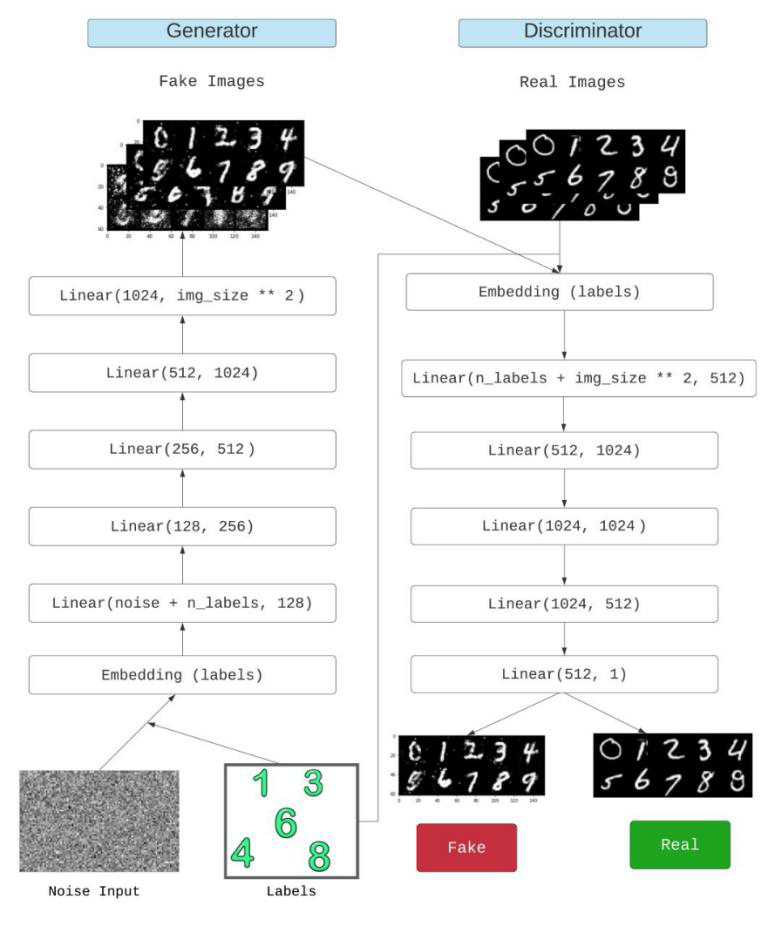

- Arsitektur yang dibangun merupakan **Conditional GAN (cGAN)**.
- Baik **Generator** maupun **Discriminator** mengondisikan prosesnya pada **label kelas** menggunakan mekanisme **label embedding**.
- Dengan pendekatan ini, Generator dapat menghasilkan gambar sesuai kelas yang diinginkan, yaitu **Stadium** atau **Oil Gas Field**.

### Generator
- Input terdiri dari:
  - **Noise vector** berdimensi **100**.
  - **Label kelas** yang diproses melalui **Embedding layer**, kemudian di-*flatten*.
- Noise dan label digabungkan menggunakan operasi **concatenate**.
- Hasil penggabungan diproses melalui empat **Dense layer** dengan ukuran:
  - 128
  - 256
  - 512
  - 1024
- Setiap Dense layer diikuti oleh aktivasi **LeakyReLU (α = 0.2)** untuk menghindari **dying ReLU problem**, yaitu kondisi ketika neuron berhenti menghasilkan gradient sehingga tidak lagi belajar.
- Layer output berupa:
  - **Dense(784)** dengan aktivasi **tanh**.
  - Output kemudian di-*reshape* menjadi citra berukuran **(28, 28, 1)**.

### Discriminator

- Input terdiri dari:
  - Gambar yang di-*flatten* menjadi vektor berukuran **784**.
  - Label kelas yang diproses melalui **Embedding layer**.
- Gambar dan label digabungkan menggunakan operasi **concatenate**.
- Hasil penggabungan diproses melalui empat **Dense layer** dengan ukuran:
  - 512
  - 1024
  - 1024
  - 512
- Setiap Dense layer menggunakan aktivasi **LeakyReLU (α = 0.2)**.
- Layer output berupa **Dense(1)** dengan aktivasi **sigmoid** yang menghasilkan probabilitas apakah gambar merupakan **gambar asli** atau **gambar sintetis**.

### Implementasi
- Arsitektur diimplementasikan menggunakan **TensorFlow/Keras Functional API**.
- Functional API memungkinkan dua input (gambar/noise dan label) diproses secara paralel sebelum digabungkan dalam satu aliran komputasi.

In [ ]:
# === Konfigurasi GAN =========================================================
IMG_SIZE = 28
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 1)
NOISE_DIM = 100
N_CLASSES = 2    # Stadium, Oil Gas Field
EMBED_DIM = 50   # dimensi embedding label

# === GENERATOR ===============================================================
def build_generator(noise_dim=NOISE_DIM, n_classes=N_CLASSES, embed_dim=EMBED_DIM, img_size=IMG_SIZE):
    """
    Conditional Generator (bottom-up):
        Noise Input + Labels
            -> Embedding(labels)
            -> concat([noise, label_embed])          # Linear(noise + n_labels, 128)
            -> Dense(128)  -> LeakyReLU(0.2)
            -> Dense(256)  -> LeakyReLU(0.2)
            -> Dense(512)  -> LeakyReLU(0.2)
            -> Dense(1024) -> LeakyReLU(0.2)
            -> Dense(img_size ** 2) -> Tanh
            -> Reshape(img_size, img_size, 1)
    """
    noise_inp = layers.Input(shape=(noise_dim,), name='noise_input')
    label_inp = layers.Input(shape=(1,), name='label_input')

    label_emb = layers.Embedding(n_classes, embed_dim, name='gen_embedding')(label_inp)
    label_emb = layers.Flatten(name='gen_emb_flatten')(label_emb)

    x = layers.Concatenate(name='gen_concat')([noise_inp, label_emb])

    for i, units in enumerate([128, 256, 512, 1024]):
        x = layers.Dense(units, name=f'gen_dense_{i}_{units}')(x)
        x = layers.LeakyReLU(0.2, name=f'gen_lrelu_{i}_{units}')(x)

    x   = layers.Dense(img_size * img_size, activation='tanh', name='gen_out_flat')(x)
    out = layers.Reshape((img_size, img_size, 1), name='gen_output')(x)

    return Model([noise_inp, label_inp], out, name='baseline_generator')


# === DISCRIMINATOR ===========================================================
def build_discriminator(n_classes=N_CLASSES, embed_dim=EMBED_DIM, img_size=IMG_SIZE):
    """
    Conditional Discriminator (top-down):
        Real/Fake Images + Embedding(labels)
            -> concat([flatten(img), label_embed])   # Linear(n_labels + img_size**2, 512)
            -> Dense(512)  -> LeakyReLU(0.2)
            -> Dense(1024) -> LeakyReLU(0.2)
            -> Dense(1024) -> LeakyReLU(0.2)
            -> Dense(512)  -> LeakyReLU(0.2)
            -> Dense(1)    -> Sigmoid
    """
    img_inp   = layers.Input(shape=(img_size, img_size, 1), name='img_input')
    label_inp = layers.Input(shape=(1,), name='label_input')

    img_flat  = layers.Flatten(name='dis_img_flatten')(img_inp)
    label_emb = layers.Embedding(n_classes, embed_dim, name='dis_embedding')(label_inp)
    label_emb = layers.Flatten(name='dis_emb_flatten')(label_emb)

    x = layers.Concatenate(name='dis_concat')([img_flat, label_emb])

    for i, units in enumerate([512, 1024, 1024, 512]):
        x = layers.Dense(units, name=f'dis_dense_{i}_{units}')(x)
        x = layers.LeakyReLU(0.2, name=f'dis_lrelu_{i}_{units}')(x)

    out = layers.Dense(1, activation='sigmoid', name='dis_output')(x)

    return Model([img_inp, label_inp], out, name='baseline_discriminator')


# Preview
gen = build_generator()
dis = build_discriminator()
gen.summary()
print()
dis.summary()

I0000 00:00:1782672758.680787      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782672758.686901      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "baseline_generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gen_embedding       │ (None, 1, 50)     │        100 │ label_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise_input         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gen_emb_flatten     │ (None, 50)        │          0 │ gen_embedding[0]… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gen_concat          │ (None, 150)       │          0 │ noise_input[0][0… │
│ (Concatenate)       │                   │            │ gen_emb_flatten[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gen_dense_0_128     │ (None, 128)       │     19,328 │ gen_concat[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gen_lrelu_0_128     │ (None, 128)       │          0 │ gen_dense_0_128[… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gen_dense_1_256     │ (None, 256)       │     33,024 │ gen_lrelu_0_128[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gen_lrelu_1_256     │ (None, 256)       │          0 │ gen_dense_1_256[… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gen_dense_2_512     │ (None, 512)       │    131,584 │ gen_lrelu_1_256[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gen_lrelu_2_512     │ (None, 512)       │          0 │ gen_dense_2_512[… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gen_dense_3_1024    │ (None, 1024)      │    525,312 │ gen_lrelu_2_512[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gen_lrelu_3_1024    │ (None, 1024)      │          0 │ gen_dense_3_1024… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gen_out_flat        │ (None, 784)       │    803,600 │ gen_lrelu_3_1024… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gen_output          │ (None, 28, 28, 1) │          0 │ gen_out_flat[0][… │
│ (Reshape)           │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,512,948 (5.77 MB)

 Trainable params: 1,512,948 (5.77 MB)

...

Model: "baseline_discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_input           │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dis_embedding       │ (None, 1, 50)     │        100 │ label_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dis_img_flatten     │ (None, 784)       │          0 │ img_input[0][0]   │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dis_emb_flatten     │ (None, 50)        │          0 │ dis_embedding[0]… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dis_concat          │ (None, 834)       │          0 │ dis_img_flatten[… │
│ (Concatenate)       │                   │            │ dis_emb_flatten[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dis_dense_0_512     │ (None, 512)       │    427,520 │ dis_concat[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dis_lrelu_0_512     │ (None, 512)       │          0 │ dis_dense_0_512[… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dis_dense_1_1024    │ (None, 1024)      │    525,312 │ dis_lrelu_0_512[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dis_lrelu_1_1024    │ (None, 1024)      │          0 │ dis_dense_1_1024… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dis_dense_2_1024    │ (None, 1024)      │  1,049,600 │ dis_lrelu_1_1024… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dis_lrelu_2_1024    │ (None, 1024)      │          0 │ dis_dense_2_1024… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dis_dense_3_512     │ (None, 512)       │    524,800 │ dis_lrelu_2_1024… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dis_lrelu_3_512     │ (None, 512)       │          0 │ dis_dense_3_512[… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dis_output (Dense)  │ (None, 1)         │        513 │ dis_lrelu_3_512[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,527,845 (9.64 MB)

 Trainable params: 2,527,845 (9.64 MB)

 Non-trainable params: 0 (0.00 B)

### Pelatihan Baseline GAN

GAN dilatih menggunakan prosedur standar dua fase yang dijalankan bergantian pada setiap batch. Pada fase pertama, **Discriminator diperbarui**: Generator di-freeze, kemudian Discriminator menerima batch gambar asli (diberi target label = 1) dan batch gambar palsu dari Generator (diberi target label = 0). Gradien dihitung dan bobot Discriminator diperbarui untuk meminimalkan total loss klasifikasi. Pada fase kedua, **Generator diperbarui**: Discriminator di-freeze, Generator menghasilkan batch gambar palsu dan gambar tersebut dilewatkan ke Discriminator, tetapi kali ini target label-nya adalah 1 (seolah-olah gambar tersebut asli). Dengan cara ini, Generator menerima sinyal gradient untuk menghasilkan gambar yang semakin sulit dibedakan oleh Discriminator.

Optimizer yang digunakan adalah **Adam dengan `lr=2e-4` dan `beta_1=0.5`**, yaitu kombinasi yang sudah menjadi praktik standar dalam pelatihan GAN sejak diperkenalkan oleh DCGAN. Nilai `beta_1=0.5` (alih-alih default 0.9) dipilih secara sengaja karena momentum yang lebih rendah membantu stabilitas training. Baseline GAN dilatih selama **50 epoch** sebagai titik referensi awal.

In [ ]:
# === Training Loop GAN =======================================================

@tf.function
def train_step_discriminator(real_imgs, real_labels, generator, discriminator, d_optimizer, noise_dim, batch_size):
    """Satu step update Discriminator."""
    noise = tf.random.normal([batch_size, noise_dim])
    fake_labels = tf.random.uniform([batch_size, 1], 0, 2, dtype=tf.int32)
    fake_imgs = generator([noise, fake_labels], training=False)

    with tf.GradientTape() as tape:
        real_pred = discriminator([real_imgs, real_labels], training=True)
        fake_pred = discriminator([fake_imgs, fake_labels], training=True)
        real_loss = tf.keras.losses.binary_crossentropy(tf.ones_like(real_pred),  real_pred)
        fake_loss = tf.keras.losses.binary_crossentropy(tf.zeros_like(fake_pred), fake_pred)
        d_loss = tf.reduce_mean(real_loss + fake_loss)

    grads = tape.gradient(d_loss, discriminator.trainable_variables)
    d_optimizer.apply_gradients(zip(grads, discriminator.trainable_variables))
    return d_loss


@tf.function
def train_step_generator(generator, discriminator, g_optimizer, noise_dim, batch_size):
    """Satu step update Generator."""
    noise = tf.random.normal([batch_size, noise_dim])
    fake_labels = tf.random.uniform([batch_size, 1], 0, 2, dtype=tf.int32)

    with tf.GradientTape() as tape:
        fake_imgs = generator([noise, fake_labels], training=True)
        fake_pred = discriminator([fake_imgs, fake_labels], training=False)
        g_loss = tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(tf.ones_like(fake_pred), fake_pred)
        )

    grads = tape.gradient(g_loss, generator.trainable_variables)
    g_optimizer.apply_gradients(zip(grads, generator.trainable_variables))
    return g_loss


def train_gan(generator, discriminator, X_train, y_train, epochs=50, batch_size=64, noise_dim=NOISE_DIM, d_lr=2e-4, g_lr=2e-4, verbose_every=5):
    """Loop pelatihan GAN lengkap."""
    d_optimizer = Adam(d_lr, beta_1=0.5)
    g_optimizer = Adam(g_lr, beta_1=0.5)

    dataset = tf.data.Dataset.from_tensor_slices(
        (X_train.astype('float32'), y_train.reshape(-1, 1).astype('int32'))
    ).shuffle(len(X_train), seed=SEED).batch(batch_size, drop_remainder=True)

    history = {'d_loss': [], 'g_loss': []}

    for epoch in range(1, epochs + 1):
        d_losses, g_losses = [], []

        for real_imgs, real_labels in dataset:
            bs = tf.shape(real_imgs)[0]
            d_l = train_step_discriminator(real_imgs, real_labels, generator, discriminator, d_optimizer, noise_dim, bs)
            g_l = train_step_generator(generator, discriminator, g_optimizer, noise_dim, bs)
            d_losses.append(float(d_l))
            g_losses.append(float(g_l))

        history['d_loss'].append(np.mean(d_losses))
        history['g_loss'].append(np.mean(g_losses))

        if epoch % verbose_every == 0 or epoch == 1:
            print(f"Epoch [{epoch:3d}/{epochs}]  "
                  f"D Loss: {history['d_loss'][-1]:.4f}  "
                  f"G Loss: {history['g_loss'][-1]:.4f}")

    return history


# Build dan latih baseline GAN
tf.random.set_seed(SEED)
baseline_gen = build_generator()
baseline_dis = build_discriminator()

print("Melatih Baseline GAN...")
history_baseline = train_gan(
    baseline_gen, baseline_dis,
    X_train_g, y_train_g,
    epochs=50, batch_size=64,
    d_lr=2e-4, g_lr=2e-4,
    verbose_every=5,
)

Melatih Baseline GAN...
Epoch [  1/50]  D Loss: 0.9704  G Loss: 1.5490
Epoch [  5/50]  D Loss: 0.9886  G Loss: 1.6699
Epoch [ 10/50]  D Loss: 1.0401  G Loss: 1.6152
Epoch [ 15/50]  D Loss: 1.0205  G Loss: 1.5921
Epoch [ 20/50]  D Loss: 1.0652  G Loss: 1.5187
Epoch [ 25/50]  D Loss: 1.0542  G Loss: 1.4881
Epoch [ 30/50]  D Loss: 1.0917  G Loss: 1.3865
Epoch [ 35/50]  D Loss: 1.0672  G Loss: 1.4091
Epoch [ 40/50]  D Loss: 1.0933  G Loss: 1.3589
Epoch [ 45/50]  D Loss: 1.0804  G Loss: 1.3904
Epoch [ 50/50]  D Loss: 1.0553  G Loss: 1.4218


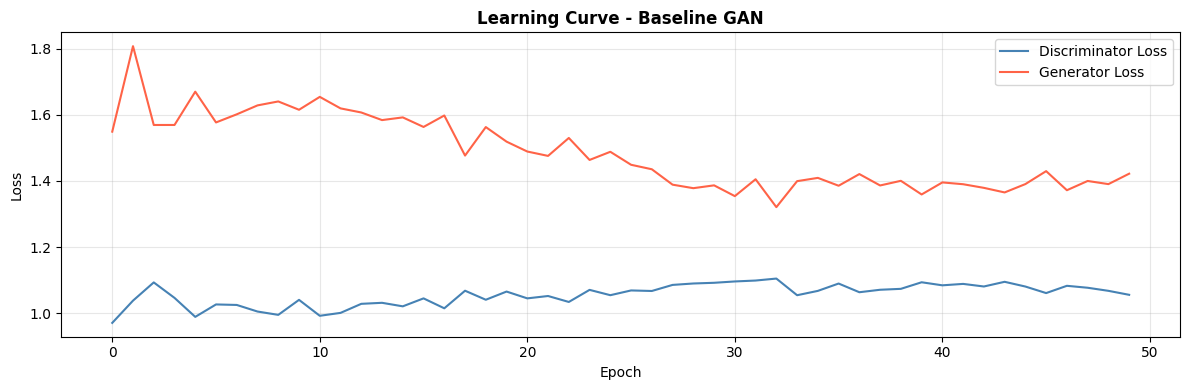

In [ ]:
# Plot learning curve baseline GAN
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(history_baseline['d_loss'], label='Discriminator Loss', color='steelblue')
ax.plot(history_baseline['g_loss'], label='Generator Loss', color='tomato')
ax.set_title('Learning Curve - Baseline GAN', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

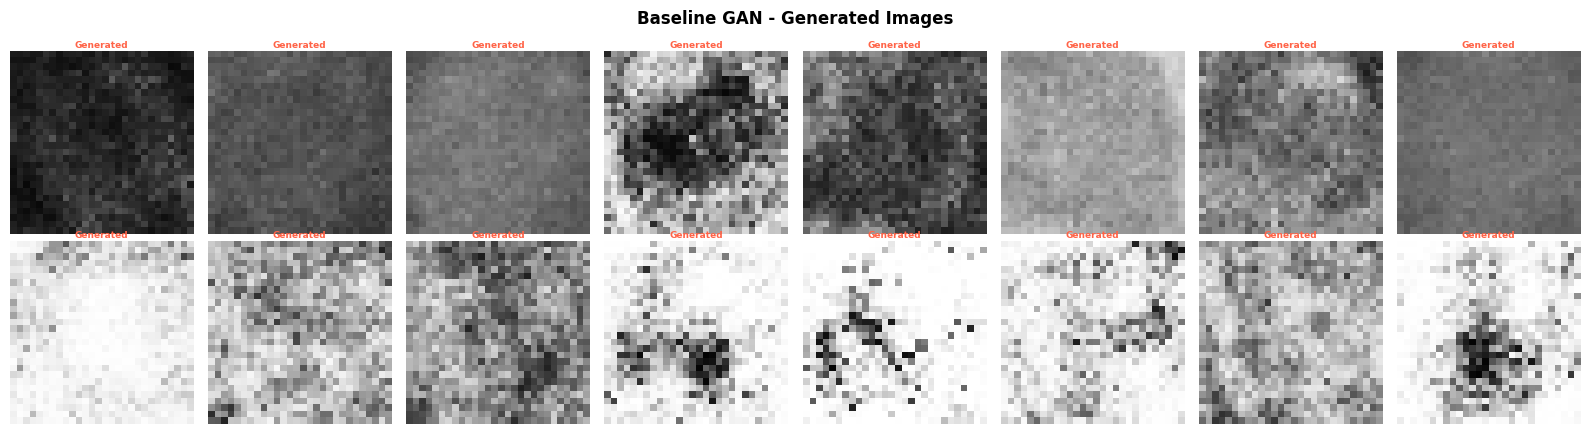

In [ ]:
def visualize_generated(generator, n_per_class=8, noise_dim=NOISE_DIM, title='Generated Images', class_names=None):
    """Tampilkan gambar yang dihasilkan Generator per kelas."""
    fig, axes = plt.subplots(N_CLASSES, n_per_class, figsize=(n_per_class * 2, N_CLASSES * 2.2))
    fig.suptitle(title, fontsize=12, fontweight='bold')

    for class_id in range(N_CLASSES):
        noise = tf.random.normal([n_per_class, noise_dim], seed=SEED + class_id)
        label_input = tf.fill([n_per_class, 1], class_id)
        fake_imgs = generator([noise, label_input], training=False).numpy()

        for j in range(n_per_class):
            ax = axes[class_id, j]
            ax.imshow((fake_imgs[j, :, :, 0] + 1) / 2, cmap='gray', vmin=0, vmax=1)
            ax.axis('off')
            ax.set_title('Generated', fontsize=6.5, color='tomato', fontweight='bold', pad=2)
            if j == 0 and class_names:
                ax.set_ylabel(class_names[class_id], fontsize=8, fontweight='bold', rotation=90)

    plt.tight_layout()
    plt.show()

visualize_generated(baseline_gen, title='Baseline GAN - Generated Images', class_names=class_names)

### Evaluasi Baseline GAN: FID pada Test Set

**Fréchet Inception Distance (FID)** adalah metrik standar industri untuk mengukur kualitas gambar yang dihasilkan oleh model generatif. Cara kerjanya adalah dengan mengekstrak representasi fitur dari gambar asli dan gambar Generated menggunakan model **InceptionV3** yang telah dilatih pada ImageNet. Kemudian, distribusi statistik dari kedua kumpulan fitur tersebut dibandingkan menggunakan jarak Fréchet antara dua distribusi Gaussian multivariat: `FID = ||μ_r - μ_f||² + Tr(Σ_r + Σ_f - 2(Σ_r Σ_f)^(1/2))`. Karena gambar Overhead-MNIST berukuran 28×28 (terlalu kecil untuk InceptionV3 yang membutuhkan minimal 75×75) gambar diupscale terlebih dahulu menggunakan `tf.image.resize` sebelum diproses.

Semakin kecil nilai FID, semakin dekat distribusi gambar Generated dengan distribusi gambar asli, baik dari segi kualitas visual maupun keragaman (*diversity*). Nilai FID baseline pada test set menjadi titik referensi yang akan dibandingkan dengan FID model Improved GAN pada bagian (c).

In [ ]:
# === FID Helper ==============================================================
def get_inception_features(images_uint8, batch_size=64):
    """
    Ekstrak feature dari InceptionV3 pretrained.
    images_uint8: (N, 28, 28, 1) uint8 [0, 255]
    """
    images_resized = tf.image.resize(images_uint8, (75, 75))
    images_rgb = tf.image.grayscale_to_rgb(images_resized)
    images_preproc = keras.applications.inception_v3.preprocess_input(images_rgb)

    inception = keras.applications.InceptionV3(
        include_top=False, pooling='avg',
        input_shape=(75, 75, 3), weights='imagenet'
    )

    features = []
    for i in range(0, len(images_preproc), batch_size):
        batch = images_preproc[i:i+batch_size]
        feat = inception.predict(batch, verbose=0)
        features.append(feat)
    return np.concatenate(features, axis=0)


def compute_fid(real_images, fake_images):
    """
    Hitung Frechet Inception Distance antara real dan fake images.
    Input: (N, 28, 28, 1) float32 [-1, 1]
    """
    real_uint8 = tf.cast((real_images + 1) * 127.5, tf.uint8)
    fake_uint8 = tf.cast((fake_images + 1) * 127.5, tf.uint8)

    print("  Ekstrak fitur gambar asli...")
    mu_r = np.mean(get_inception_features(real_uint8), axis=0)
    sigma_r = np.cov(get_inception_features(real_uint8), rowvar=False)
    print("  Ekstrak fitur gambar generated...")
    mu_f = np.mean(get_inception_features(fake_uint8), axis=0)
    sigma_f = np.cov(get_inception_features(fake_uint8), rowvar=False)

    diff = mu_r - mu_f
    covmean = linalg.sqrtm(sigma_r.dot(sigma_f))
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = diff.dot(diff) + np.trace(sigma_r + sigma_f - 2 * covmean)
    return float(fid)

In [ ]:
# Generate gambar sebanyak test set untuk evaluasi FID baseline
n_eval = len(X_test_g)
noise_eval  = tf.random.normal([n_eval, NOISE_DIM], seed=SEED)
labels_eval = tf.cast(
    tf.concat([tf.fill([n_eval//2, 1], 0), tf.fill([n_eval - n_eval//2, 1], 1)], axis=0),
    tf.int32
)
fake_imgs_baseline = baseline_gen([noise_eval, labels_eval], training=False).numpy()

print("Menghitung FID baseline...")
fid_baseline = compute_fid(X_test_g, fake_imgs_baseline)
print(f"\nFID Baseline GAN : {fid_baseline:.2f}")

Menghitung FID baseline...
  Ekstrak fitur gambar asli...
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


I0000 00:00:1782672882.902350      69 service.cc:152] XLA service 0x797e387dc8a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782672882.902399      69 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782672882.902403      69 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782672884.317787      69 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1782672889.399849      69 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  Ekstrak fitur gambar generated...

FID Baseline GAN : 387.87


/tmp/ipykernel_23/2001427945.py:40: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = linalg.sqrtm(sigma_r.dot(sigma_f))


### d. [LO 1, LO 2, LO 3, LO 4, 10 poin] Setelah mengetahui hasil dari nomor (3b), modifikasi arsitektur GAN di atas agar mendapatkan metrik Fréchet Inception Distance (FID) yang lebih baik. Berikan alasan mengapa modifikasi arsitektur dan metode tuning hyperparameter kalian lebih baik.

Berdasarkan hasil baseline, dilakukan beberapa modifikasi utama untuk meningkatkan kualitas gambar yang dihasilkan:

### Generator
1. Mengganti arsitektur **Dense** menjadi **DCGAN-style** berbasis konvolusi agar mampu menangkap hubungan spasial antarpiksel karena Dense memperlakukan setiap piksel secara independen sedangkan Conv2D mampu mempelajari pola lokal seperti tepi, tekstur, dan bentuk objek sehingga gambar yang dihasilkan lebih realistis.
2. Menggunakan **Conv2DTranspose** untuk melakukan upsampling bertahap dari **7×7 -> 14×14 -> 28×28** sehingga generator dapat membangun struktur gambar dari fitur kasar hingga detail halus secara bertahap.
3. Menambahkan **Batch Normalization** setelah setiap Conv2DTranspose untuk menstabilkan pelatihan, mempercepat konvergensi, dan menjaga distribusi aktivasi tetap stabil selama proses pembelajaran.
4. Menambahkan **refinement Conv2D** sebelum layer output untuk mengurangi artefak *checkerboard* sehingga hasil upsampling menjadi lebih halus dan tampak lebih alami.
5. Menggunakan **Conv2D + Tanh** sebagai layer output untuk menghasilkan citra grayscale dengan rentang **[-1, 1]** sehingga sesuai dengan rentang normalisasi data dan membuat proses pelatihan lebih stabil.
6. Tetap mempertahankan **conditional label embedding** di mana label kelas terlebih dahulu diubah menjadi representasi vektor melalui **Embedding layer**, kemudian digabungkan (*concatenate*) dengan noise. Dengan demikian generator, tidak hanya menghasilkan gambar yang realistis, tetapi juga dapat mengontrol kelas gambar yang dihasilkan sesuai label yang diberikan.
7. Menggunakan **LeakyReLU (α = 0.2)** sebagai fungsi aktivasi pada setiap hidden layer untuk menjaga aliran gradien tetap ada ketika nilai aktivasi bernilai negatif sehingga mengurangi risiko *dead neuron* dan membantu proses pelatihan menjadi lebih stabil.

### Discriminator
1. Mengganti arsitektur **Dense** menjadi **Conv2D** agar dapat mempelajari fitur lokal seperti tepi, tekstur, dan pola spasial, karena konvolusi mempertahankan informasi spasial yang penting dalam citra.
2. Menggunakan **Conv2D (stride = 2)** untuk downsampling bertahap sekaligus meningkatkan jumlah feature map, sehingga fitur yang dipelajari menjadi lebih representatif dengan kompleksitas komputasi yang lebih rendah.
3. Menggunakan **SpatialDropout2D (0.3)** sebagai regularisasi yang lebih efektif pada feature map konvolusional dibanding Dropout biasa karena menghilangkan seluruh feature map secara acak sehingga mengurangi ketergantungan antarfitur yang berkorelasi dan membantu mencegah overfitting.
4. Menggunakan **Dense(128) -> Dense(1) + Sigmoid** pada tahap akhir untuk menghasilkan probabilitas klasifikasi **real/fake** sehingga discriminator dapat melakukan klasifikasi biner secara efektif.
5. Mengubah mekanisme **conditional input** dari sekadar menggabungkan embedding dengan vektor hasil flatten menjadi **label map**. Label diubah menjadi representasi berukuran **28×28**, kemudian dikonkatenasikan sebagai kanal tambahan pada citra masukan sehingga informasi kelas tersedia sejak lapisan konvolusi pertama dan discriminator dapat mempelajari hubungan antara isi gambar dengan label yang diberikan.
6. Menggunakan **LeakyReLU (α = 0.2)** pada setiap layer konvolusi dan dense untuk mempertahankan aliran gradien selama proses *backpropagation*, mengurangi kemungkinan terjadinya *dead neuron*, serta meningkatkan stabilitas pelatihan GAN.

In [ ]:
# === Improved Generator (DCGAN-style, conditional via concat noise+label) ====
def build_improved_generator(noise_dim=NOISE_DIM, n_classes=N_CLASSES, embed_dim=50, img_size=IMG_SIZE):
    """
    Improved Generator (konvolusional, menggantikan Dense murni pada baseline):
        noise + label_embedding -> concat
            -> Dense projection ke (7, 7, 128) + BN + LeakyReLU
            -> Conv2DTranspose -> (14, 14, 64)  + BN + LeakyReLU
            -> Conv2DTranspose -> (28, 28, 32)  + BN + LeakyReLU
            -> Conv2D refine   -> (28, 28, 32)  + BN + LeakyReLU
            -> Conv2D output   -> (28, 28, 1)   + Tanh
    """
    noise_inp = layers.Input(shape=(noise_dim,), name='noise_input')
    label_inp = layers.Input(shape=(1,), name='label_input')

    label_emb = layers.Embedding(n_classes, embed_dim, name='g_label_embedding')(label_inp)
    label_emb = layers.Flatten(name='g_label_flatten')(label_emb)

    x = layers.Concatenate(name='g_noise_label_concat')([noise_inp, label_emb])

    init_h = init_w = img_size // 4  # 7 untuk img_size=28
    x = layers.Dense(init_h * init_w * 128, use_bias=False, name='g_dense_project')(x)
    x = layers.BatchNormalization(momentum=0.8, name='g_bn0')(x)
    x = layers.LeakyReLU(0.2, name='g_lrelu0')(x)
    x = layers.Reshape((init_h, init_w, 128), name='g_reshape')(x)

    x = layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding='same', use_bias=False, name='g_convT1')(x)
    x = layers.BatchNormalization(momentum=0.8, name='g_bn1')(x)
    x = layers.LeakyReLU(0.2, name='g_lrelu1')(x)

    x = layers.Conv2DTranspose(32, kernel_size=4, strides=2, padding='same', use_bias=False, name='g_convT2')(x)
    x = layers.BatchNormalization(momentum=0.8, name='g_bn2')(x)
    x = layers.LeakyReLU(0.2, name='g_lrelu2')(x)

    # extra refinement conv sebelum output untuk menghaluskan
    # tekstur hasil upsampling Conv2DTranspose (mengurangi artefak checkerboard).
    x = layers.Conv2D(32, kernel_size=3, padding='same', use_bias=False, name='g_refine_conv')(x)
    x = layers.BatchNormalization(momentum=0.8, name='g_bn_refine')(x)
    x = layers.LeakyReLU(0.2, name='g_lrelu_refine')(x)

    out = layers.Conv2D(1, kernel_size=3, padding='same', activation='tanh', name='g_output_tanh')(x)

    return Model([noise_inp, label_inp], out, name='improved_generator')


# === Improved Discriminator (DCGAN-style, label sebagai channel tambahan) ====
def build_improved_discriminator(n_classes=N_CLASSES, img_size=IMG_SIZE, dropout_rate=0.3):
    """
    Improved Discriminator (konvolusional, menggantikan Dense murni pada baseline):
        image + label_embedding (di-reshape jadi channel tambahan) -> concat
            -> Conv2D -> (14, 14, 64) + LeakyReLU + SpatialDropout2D
            -> Conv2D -> (7,  7, 128) + LeakyReLU + SpatialDropout2D
            -> Flatten -> Dense(128) + LeakyReLU
            -> Dense(1) + Sigmoid

    Sedikit perubahan dari arsitektur dasar: dropout pada feature map konvolusi
    memakai SpatialDropout2D (men-drop seluruh channel) bukan Dropout biasa
    (men-drop piksel acak), karena untuk feature map konvolusi yang piksel-
    pikselnya saling berkorelasi secara spasial, channel-wise dropout terbukti
    lebih efektif mencegah overfitting.
    """
    img_inp   = layers.Input(shape=(img_size, img_size, 1), name='img_input')
    label_inp = layers.Input(shape=(1,), name='label_input')

    label_emb = layers.Embedding(n_classes, img_size * img_size, name='d_label_embedding')(label_inp)
    label_map = layers.Reshape((img_size, img_size, 1), name='d_label_map')(label_emb)

    x = layers.Concatenate(name='d_image_label_concat')([img_inp, label_map])

    x = layers.Conv2D(64, kernel_size=4, strides=2, padding='same', name='d_conv1')(x)
    x = layers.LeakyReLU(0.2, name='d_lrelu1')(x)
    x = layers.SpatialDropout2D(dropout_rate, name='d_dropout1')(x)

    x = layers.Conv2D(128, kernel_size=4, strides=2, padding='same', name='d_conv2')(x)
    x = layers.LeakyReLU(0.2, name='d_lrelu2')(x)
    x = layers.SpatialDropout2D(dropout_rate, name='d_dropout2')(x)

    x = layers.Flatten(name='d_flatten')(x)
    x = layers.Dense(128, name='d_dense')(x)
    x = layers.LeakyReLU(0.2, name='d_lrelu3')(x)

    out = layers.Dense(1, activation='sigmoid', name='d_output')(x)

    return Model([img_inp, label_inp], out, name='improved_discriminator')


# Preview improved
imp_gen = build_improved_generator()
imp_gen.summary()
print()
imp_dis = build_improved_discriminator()
imp_dis.summary()

Model: "improved_generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_label_embedding   │ (None, 1, 50)     │        100 │ label_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise_input         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_label_flatten     │ (None, 50)        │          0 │ g_label_embeddin… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_noise_label_conc… │ (None, 150)       │          0 │ noise_input[0][0… │
│ (Concatenate)       │                   │            │ g_label_flatten[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_dense_project     │ (None, 6272)      │    940,800 │ g_noise_label_co… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_bn0               │ (None, 6272)      │     25,088 │ g_dense_project[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_lrelu0            │ (None, 6272)      │          0 │ g_bn0[0][0]       │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_reshape (Reshape) │ (None, 7, 7, 128) │          0 │ g_lrelu0[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_convT1            │ (None, 14, 14,    │    131,072 │ g_reshape[0][0]   │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_bn1               │ (None, 14, 14,    │        256 │ g_convT1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_lrelu1            │ (None, 14, 14,    │          0 │ g_bn1[0][0]       │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_convT2            │ (None, 28, 28,    │     32,768 │ g_lrelu1[0][0]    │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_bn2               │ (None, 28, 28,    │        128 │ g_convT2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_lrelu2            │ (None, 28, 28,    │          0 │ g_bn2[0][0]       │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_refine_conv       │ (None, 28, 28,    │      9,216 │ g_lrelu2[0][0]    │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_bn_refine         │ (None, 28, 28,    │        128 │ g_refine_conv[0]… │
│ (BatchNormalizatio… │ 32)               │            │                 

 Total params: 1,139,845 (4.35 MB)

 Trainable params: 1,127,045 (4.30 MB)

 Non-trainable params: 12,800 (50.00 KB)

Model: "improved_discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d_label_embedding   │ (None, 1, 784)    │      1,568 │ label_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_input           │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d_label_map         │ (None, 28, 28, 1) │          0 │ d_label_embeddin… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d_image_label_conc… │ (None, 28, 28, 2) │          0 │ img_input[0][0],  │
│ (Concatenate)       │                   │            │ d_label_map[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d_conv1 (Conv2D)    │ (None, 14, 14,    │      2,112 │ d_image_label_co… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d_lrelu1            │ (None, 14, 14,    │          0 │ d_conv1[0][0]     │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d_dropout1          │ (None, 14, 14,    │          0 │ d_lrelu1[0][0]    │
│ (SpatialDropout2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d_conv2 (Conv2D)    │ (None, 7, 7, 128) │    131,200 │ d_dropout1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d_lrelu2            │ (None, 7, 7, 128) │          0 │ d_conv2[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d_dropout2          │ (None, 7, 7, 128) │          0 │ d_lrelu2[0][0]    │
│ (SpatialDropout2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d_flatten (Flatten) │ (None, 6272)      │          0 │ d_dropout2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d_dense (Dense)     │ (None, 128)       │    802,944 │ d_flatten[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d_lrelu3            │ (None, 128)       │          0 │ d_dense[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d_output (Dense)    │ (None, 1)         │        129 │ d_lrelu3[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 937,953 (3.58 MB)

 Trainable params: 937,953 (3.58 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def train_step_discriminator_improved(real_imgs, real_labels, generator, discriminator, d_optimizer, noise_dim, batch_size, smooth_real=0.9):
    """D step dengan label smoothing: real=smooth_real, fake=0.0."""
    noise = tf.random.normal([batch_size, noise_dim])
    fake_labels = tf.random.uniform([batch_size, 1], 0, 2, dtype=tf.int32)
    fake_imgs = generator([noise, fake_labels], training=False)

    with tf.GradientTape() as tape:
        real_pred = discriminator([real_imgs,  real_labels], training=True)
        fake_pred = discriminator([fake_imgs,  fake_labels], training=True)
        real_loss = tf.keras.losses.binary_crossentropy(
            tf.ones_like(real_pred) * smooth_real, real_pred)
        fake_loss = tf.keras.losses.binary_crossentropy(
            tf.zeros_like(fake_pred), fake_pred)
        d_loss = tf.reduce_mean(real_loss + fake_loss)

    grads = tape.gradient(d_loss, discriminator.trainable_variables)
    d_optimizer.apply_gradients(zip(grads, discriminator.trainable_variables))
    return d_loss


def train_step_generator(generator, discriminator, g_optimizer, noise_dim, batch_size):
    """Satu step update Generator."""
    noise = tf.random.normal([batch_size, noise_dim])
    fake_labels = tf.random.uniform([batch_size, 1], 0, 2, dtype=tf.int32)

    with tf.GradientTape() as tape:
        fake_imgs = generator([noise, fake_labels], training=True)
        fake_pred = discriminator([fake_imgs, fake_labels], training=False)
        g_loss = tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(tf.ones_like(fake_pred), fake_pred)
        )

    grads = tape.gradient(g_loss, generator.trainable_variables)
    g_optimizer.apply_gradients(zip(grads, generator.trainable_variables))
    return g_loss


def train_gan_improved(generator, discriminator, X_train, y_train, epochs=100, batch_size=64, noise_dim=NOISE_DIM, d_lr=1e-4, g_lr=2e-4, smooth_real=0.9, verbose_every=10):
    """Loop pelatihan Improved GAN dengan label smoothing dan LR asimetris."""
    d_optimizer = Adam(d_lr, beta_1=0.5)
    g_optimizer = Adam(g_lr, beta_1=0.5)

    dataset = tf.data.Dataset.from_tensor_slices(
        (X_train.astype('float32'), y_train.reshape(-1, 1).astype('int32'))
    ).shuffle(len(X_train), seed=SEED).batch(batch_size, drop_remainder=True)

    history = {'d_loss': [], 'g_loss': []}

    for epoch in range(1, epochs + 1):
        d_losses, g_losses = [], []

        for real_imgs, real_labels in dataset:
            bs  = tf.shape(real_imgs)[0]
            d_l = train_step_discriminator_improved(
                real_imgs, real_labels, generator, discriminator,
                d_optimizer, noise_dim, bs, smooth_real)
            g_l = train_step_generator(generator, discriminator,
                                       g_optimizer, noise_dim, bs)
            d_losses.append(float(d_l))
            g_losses.append(float(g_l))

        history['d_loss'].append(np.mean(d_losses))
        history['g_loss'].append(np.mean(g_losses))

        if epoch % verbose_every == 0 or epoch == 1:
            print(f"Epoch [{epoch:3d}/{epochs}]  "
                  f"D Loss: {history['d_loss'][-1]:.4f}  "
                  f"G Loss: {history['g_loss'][-1]:.4f}")

    return history

### Hyperparameter Tuning (Improved GAN)

Setelah arsitektur Improved GAN ditetapkan, dilakukan pencarian hyperparameter terbaik melalui **manual grid search** dengan tiga konfigurasi yang masing-masing dijalankan selama 50 epoch sebagai proxy cepat sebelum pelatihan penuh. Tiga parameter yang di-sweep dipilih karena memiliki dampak paling besar terhadap stabilitas pelatihan GAN pada dataset kecil: *learning rate* Discriminator (`d_lr`), *learning rate* Generator (`g_lr`), nilai *label smoothing* untuk gambar asli (`smooth_real`), dan ukuran batch (`batch_size`).

| Config | d_lr | g_lr | smooth_real | batch_size |
|--------|------|------|-------------|------------|
| Config-A | 1e-4 | 2e-4 | 0.90 | 64 |
| Config-B | 2e-4 | 2e-4 | 0.85 | 64 |
| Config-C | 1e-4 | 3e-4 | 0.90 | 32 |

**Config-A** merupakan titik referensi yang menggunakan learning rate asimetris (d_lr lebih kecil dari g_lr). Pendekatan yang dimaksudkan agar Discriminator tidak terlalu mendominasi Generator di awal training. **Config-B** menaikkan d_lr ke nilai yang sama dengan g_lr untuk menguji apakah LR simetris menghasilkan keseimbangan yang lebih baik pada dataset sekecil ini. **Config-C** mencoba strategi yang lebih agresif untuk Generator (g_lr=3e-4) dengan batch lebih kecil (32) untuk memberikan update yang lebih sering dan beragam pada Generator. Konfigurasi terbaik dipilih berdasarkan **G Loss rata-rata terendah di 5 epoch terakhir**, yang mengindikasikan bahwa Generator paling berhasil menipu Discriminator secara konsisten.

In [ ]:
# === Hyperparameter Tuning - Improved GAN (3 config, 50 epoch per run) ======

TUNING_EPOCHS = 50

tuning_configs = [
    {'name': 'Config-A | d_lr=1e-4 | g_lr=2e-4 | smooth=0.90 | bs=64',
     'd_lr': 1e-4, 'g_lr': 2e-4, 'smooth_real': 0.90, 'batch_size': 64},
    {'name': 'Config-B | d_lr=2e-4 | g_lr=2e-4 | smooth=0.85 | bs=64',
     'd_lr': 2e-4, 'g_lr': 2e-4, 'smooth_real': 0.85, 'batch_size': 64},
    {'name': 'Config-C | d_lr=1e-4 | g_lr=3e-4 | smooth=0.90 | bs=32',
     'd_lr': 1e-4, 'g_lr': 3e-4, 'smooth_real': 0.90, 'batch_size': 32},
]

tuning_results = []

for cfg in tuning_configs:
    print(f"\n{'=' * 70}")
    print(f"Training: {cfg['name']}")
    print(f"{'=' * 70}")

    tf.random.set_seed(SEED)
    _gen = build_improved_generator()
    _dis = build_improved_discriminator()

    _hist = train_gan_improved(
        _gen, _dis, X_train_g, y_train_g,
        epochs=TUNING_EPOCHS,
        batch_size=cfg['batch_size'],
        d_lr=cfg['d_lr'],
        g_lr=cfg['g_lr'],
        smooth_real=cfg['smooth_real'],
        verbose_every=10,
    )

    final_d = np.mean(_hist['d_loss'][-5:])
    final_g = np.mean(_hist['g_loss'][-5:])
    # Kita pilih config yang G Loss-nya paling rendah (Generator paling berhasil menipu D)
    tuning_results.append({
        'config': cfg['name'],
        'params': cfg,
        'final_d_loss': final_d,
        'final_g_loss': final_g,
        'history': _hist,
    })
    print(f"  → Avg D Loss (last 5 ep): {final_d:.4f} | Avg G Loss (last 5 ep): {final_g:.4f}")

# Ringkasan
print('\n' + '=' * 70)
print('RINGKASAN HYPERPARAMETER TUNING — IMPROVED GAN')
print('=' * 70)
print(f"{'Config':<52} {'D Loss':>8} {'G Loss':>8}")
print('-' * 70)
for r in tuning_results:
    print(f"{r['config']:<52} {r['final_d_loss']:>8.4f} {r['final_g_loss']:>8.4f}")

# Best = G Loss terendah di 5 epoch terakhir (Generator paling konvergen)
best_tuning = min(tuning_results, key=lambda x: x['final_g_loss'])
print('=' * 70)
print(f"Best config: {best_tuning['config']}")
print(f"  D Loss : {best_tuning['final_d_loss']:.4f}")
print(f"  G Loss : {best_tuning['final_g_loss']:.4f}")


Training: Config-A | d_lr=1e-4 | g_lr=2e-4 | smooth=0.90 | bs=64
Epoch [  1/50]  D Loss: 1.1503  G Loss: 1.3216
Epoch [ 10/50]  D Loss: 1.3424  G Loss: 0.8502
Epoch [ 20/50]  D Loss: 1.3742  G Loss: 0.8094
Epoch [ 30/50]  D Loss: 1.3748  G Loss: 0.8012
Epoch [ 40/50]  D Loss: 1.3723  G Loss: 0.8082
Epoch [ 50/50]  D Loss: 1.3687  G Loss: 0.8135
  → Avg D Loss (last 5 ep): 1.3698 | Avg G Loss (last 5 ep): 0.8090

Training: Config-B | d_lr=2e-4 | g_lr=2e-4 | smooth=0.85 | bs=64
Epoch [  1/50]  D Loss: 0.9916  G Loss: 2.3796
Epoch [ 10/50]  D Loss: 1.3423  G Loss: 0.9238
Epoch [ 20/50]  D Loss: 1.3259  G Loss: 0.9518
Epoch [ 30/50]  D Loss: 1.3273  G Loss: 0.9252
Epoch [ 40/50]  D Loss: 1.3239  G Loss: 0.9422
Epoch [ 50/50]  D Loss: 1.3253  G Loss: 0.9450
  → Avg D Loss (last 5 ep): 1.3247 | Avg G Loss (last 5 ep): 0.9414

Training: Config-C | d_lr=1e-4 | g_lr=3e-4 | smooth=0.90 | bs=32
Epoch [  1/50]  D Loss: 1.2639  G Loss: 1.0564
Epoch [ 10/50]  D Loss: 1.3762  G Loss: 0.7910
Epoch [ 

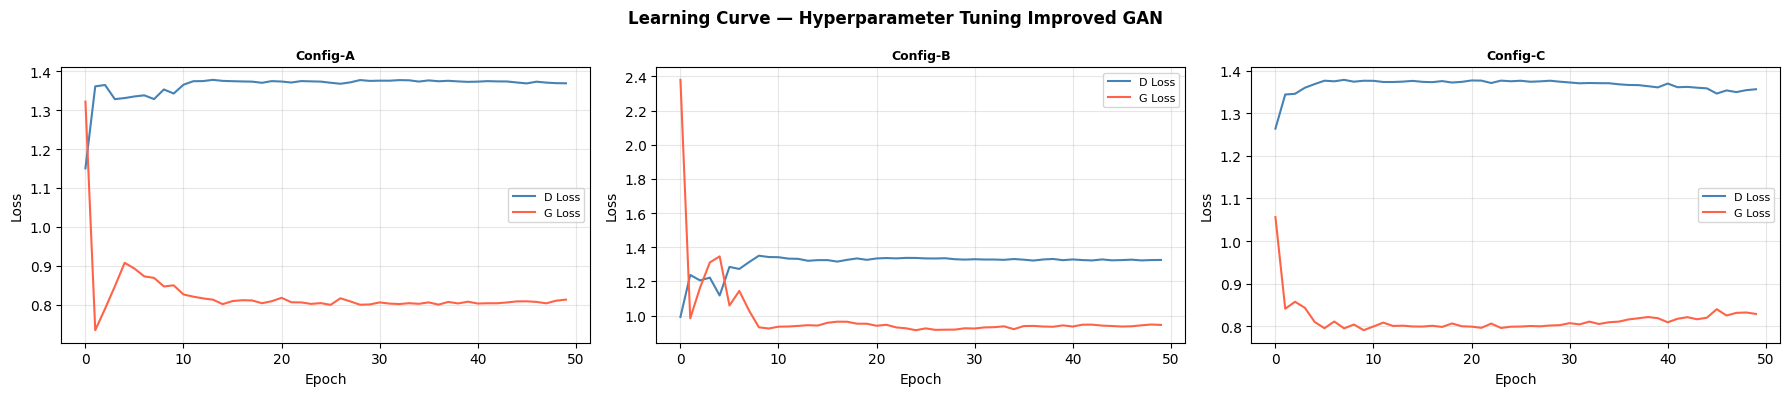

In [13]:
# Plot learning curve semua config tuning
fig, axes = plt.subplots(1, len(tuning_results), figsize=(6 * len(tuning_results), 4))
fig.suptitle('Learning Curve — Hyperparameter Tuning Improved GAN', fontsize=12, fontweight='bold')

for ax, r in zip(axes, tuning_results):
    ax.plot(r['history']['d_loss'], label='D Loss', color='steelblue')
    ax.plot(r['history']['g_loss'], label='G Loss', color='tomato')
    ax.set_title(r['config'].split('|')[0].strip(), fontsize=9, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Pelatihan Improved GAN (Best Config dari Tuning, 300 Epoch)

Berdasarkan hasil *hyperparameter tuning* di atas, konfigurasi dengan **G Loss rata-rata terendah** pada 5 epoch terakhir dipilih sebagai konfigurasi final. Model kemudian dibangun ulang dari awal (*fresh initialization*) dan dilatih selama **300 epoch** menggunakan konfigurasi tersebut. Jumlah epoch ditingkatkan dari 50 pada model baseline menjadi 300 karena generator berbasis konvolusi memiliki kapasitas yang lebih besar dibandingkan generator berbasis *Dense* sehingga memerlukan lebih banyak iterasi agar proses adversarial mencapai kondisi yang lebih stabil. Selain itu, proses upsampling bertahap menggunakan **Conv2DTranspose** mengharuskan generator mempelajari representasi spasial secara bertingkat, mulai dari struktur global hingga detail lokal. Dengan jumlah epoch yang lebih banyak, generator memiliki kesempatan lebih besar untuk menghasilkan citra yang semakin realistis dan sesuai dengan distribusi data, yang pada akhirnya diharapkan dapat menghasilkan nilai **Fréchet Inception Distance (FID)** yang lebih rendah.

Pelatihan Improved GAN juga menggunakan **label smoothing** pada Discriminator, yaitu target untuk gambar asli diset ke `smooth_real` (misalnya 0.9) alih-alih 1.0. Teknik ini mencegah Discriminator menjadi terlalu yakin pada gambar asli hingga gradiennya mengalami saturasi dan menjadi sangat kecil(kondisi yang disebut *gradient saturation*). Ketika gradient ke Generator menjadi terlalu kecil, Generator tidak mendapat sinyal yang cukup informatif untuk berkembang. Dengan melunak target sedikit, Discriminator lebih toleran dan Generator mendapat feedback yang lebih kaya untuk terus berevolusi.

In [ ]:
# === Pelatihan Improved GAN - Best Config dari Tuning, 300 Epoch =============

EPOCHS_IMPROVED = 300

# Ambil hyperparameter dari best config tuning
D_LR = best_tuning['params']['d_lr']
G_LR = best_tuning['params']['g_lr']
SMOOTH_REAL = best_tuning['params']['smooth_real']
BATCH_SIZE = best_tuning['params']['batch_size']

print(f"Best config dipilih : {best_tuning['config']}")
print(f"  d_lr={D_LR} | g_lr={G_LR} | smooth_real={SMOOTH_REAL} | batch_size={BATCH_SIZE}")
print(f"  Melatih ulang dari awal selama {EPOCHS_IMPROVED} epoch...\n")

tf.random.set_seed(SEED)
improved_gen = build_improved_generator()
improved_dis = build_improved_discriminator()

history_improved = train_gan_improved(
    improved_gen, improved_dis,
    X_train_g, y_train_g,
    epochs=EPOCHS_IMPROVED,
    batch_size=BATCH_SIZE,
    d_lr=D_LR,
    g_lr=G_LR,
    smooth_real=SMOOTH_REAL,
    verbose_every=20,
)

Best config dipilih : Config-A | d_lr=1e-4 | g_lr=2e-4 | smooth=0.90 | bs=64
  d_lr=0.0001 | g_lr=0.0002 | smooth_real=0.9 | batch_size=64
  Melatih ulang dari awal selama 300 epoch...

Epoch [  1/300]  D Loss: 1.2091  G Loss: 1.1607
Epoch [ 20/300]  D Loss: 1.3743  G Loss: 0.8023
Epoch [ 40/300]  D Loss: 1.3706  G Loss: 0.8053
Epoch [ 60/300]  D Loss: 1.3669  G Loss: 0.8155
Epoch [ 80/300]  D Loss: 1.3643  G Loss: 0.8257
Epoch [100/300]  D Loss: 1.3602  G Loss: 0.8278
Epoch [120/300]  D Loss: 1.3517  G Loss: 0.8389
Epoch [140/300]  D Loss: 1.3433  G Loss: 0.8413
Epoch [160/300]  D Loss: 1.3355  G Loss: 0.8507
Epoch [180/300]  D Loss: 1.3214  G Loss: 0.8662
Epoch [200/300]  D Loss: 1.3092  G Loss: 0.8861
Epoch [220/300]  D Loss: 1.2971  G Loss: 0.8944
Epoch [240/300]  D Loss: 1.2847  G Loss: 0.9194
Epoch [260/300]  D Loss: 1.2700  G Loss: 0.9319
Epoch [280/300]  D Loss: 1.2577  G Loss: 0.9581
Epoch [300/300]  D Loss: 1.2415  G Loss: 0.9728


In [15]:
# === Evaluasi FID pada Validation Set =========================================

n_val      = len(X_val_g)
noise_val  = tf.random.normal([n_val, NOISE_DIM], seed=SEED)
labels_val = tf.cast(
    tf.concat([tf.fill([n_val//2, 1], 0), tf.fill([n_val - n_val//2, 1], 1)], axis=0),
    tf.int32
)
fake_val = improved_gen([noise_val, labels_val], training=False).numpy()

print("Menghitung FID validation...")
fid_val_improved = compute_fid(X_val_g, fake_val)

print(f"\n{'=' * 50}")
print(f"Val FID Improved GAN (Conv-based, {EPOCHS_IMPROVED} epoch): {fid_val_improved:.2f}")
print(f"{'=' * 50}")

Menghitung FID validation...
  Ekstrak fitur gambar asli...
  Ekstrak fitur gambar generated...

Val FID Improved GAN (Conv-based, 300 epoch): 219.64


/tmp/ipykernel_23/2001427945.py:40: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = linalg.sqrtm(sigma_r.dot(sigma_f))


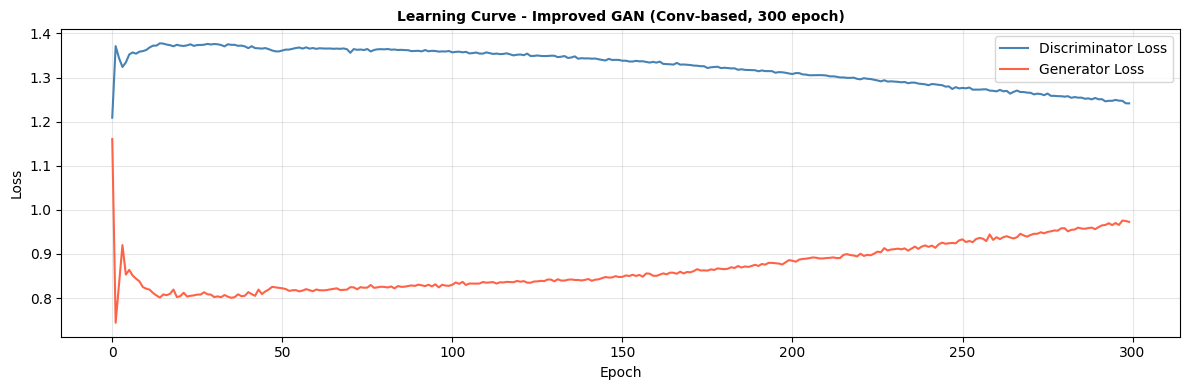

In [16]:
# Plot learning curve Improved GAN
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(history_improved['d_loss'], label='Discriminator Loss', color='steelblue')
ax.plot(history_improved['g_loss'], label='Generator Loss',     color='tomato')
ax.set_title(f'Learning Curve - Improved GAN (Conv-based, {EPOCHS_IMPROVED} epoch)',
             fontsize=10, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Evaluasi Improved GAN: FID pada Test Set

FID dihitung pada test set menggunakan prosedur yang identik dengan evaluasi baseline: sejumlah gambar sintetis yang sama dengan ukuran test set di-generate menggunakan Improved Generator yang telah dilatih, kemudian fitur InceptionV3-nya diekstrak dan jarak Fréchet dihitung terhadap distribusi fitur gambar asli test set. Konsistensi prosedur ini penting agar perbandingan antara FID baseline dan FID improved benar-benar *apple-to-apple* dan tidak ada faktor confounding seperti jumlah gambar yang berbeda atau seed yang berubah.

In [17]:
# Generate gambar sebanyak test set
n_test      = len(X_test_g)
noise_test  = tf.random.normal([n_test, NOISE_DIM], seed=SEED)
labels_test = tf.cast(
    tf.concat([tf.fill([n_test//2, 1], 0), tf.fill([n_test - n_test//2, 1], 1)], axis=0),
    tf.int32
)
fake_imgs_improved = improved_gen([noise_test, labels_test], training=False).numpy()

print("Menghitung FID improved...")
fid_improved = compute_fid(X_test_g, fake_imgs_improved)

print(f"\n{'=' * 50}")
print(f"FID Baseline GAN  : {fid_baseline:.2f}")
print(f"FID Improved GAN  : {fid_improved:.2f}")
delta = fid_baseline - fid_improved
print(f"Penurunan FID     : {delta:.2f} ({'lebih baik' if delta > 0 else 'lebih buruk'})")
print(f"{'=' * 50}")


Menghitung FID improved...
  Ekstrak fitur gambar asli...
  Ekstrak fitur gambar generated...

FID Baseline GAN  : 387.87
FID Improved GAN  : 232.11
Penurunan FID     : 155.76 (lebih baik)


/tmp/ipykernel_23/2001427945.py:40: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = linalg.sqrtm(sigma_r.dot(sigma_f))


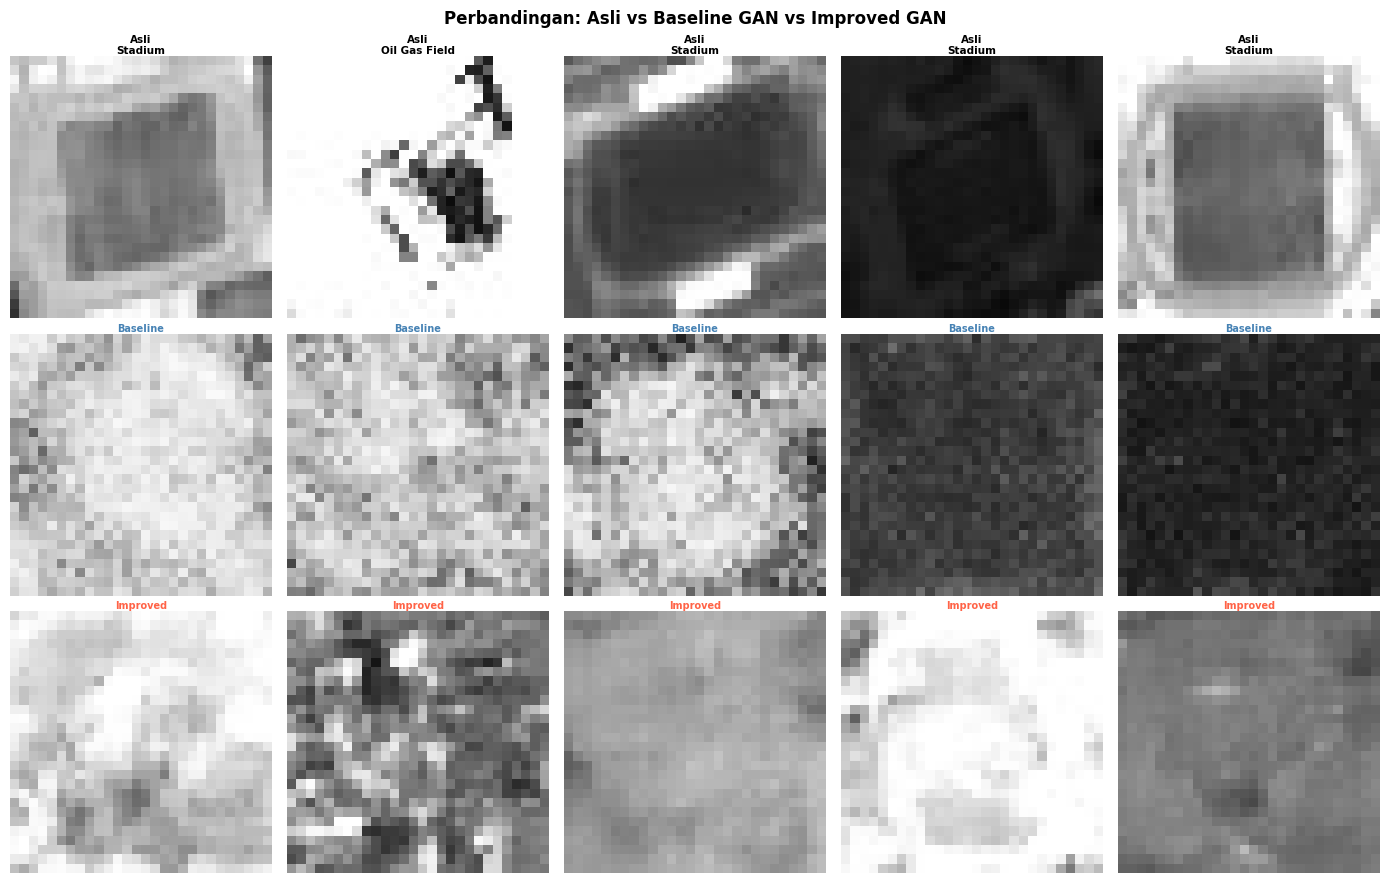

In [ ]:
# Visualisasi: Asli vs Baseline Generated vs Improved Generated
n_show = 5
fig, axes = plt.subplots(3, n_show, figsize=(n_show * 2.8, 9))
fig.suptitle('Perbandingan: Asli vs Baseline GAN vs Improved GAN', fontsize=12, fontweight='bold')

np.random.seed(SEED)
sample_idx = np.random.choice(len(X_test_g), n_show, replace=False)

row_labels = ['Gambar\nAsli', 'Baseline\nGenerated', 'Improved\nGenerated']
row_colors = ['black', 'steelblue', 'tomato']

noise_sample  = tf.random.normal([n_show, NOISE_DIM], seed=SEED)
labels_sample = tf.cast(
    tf.constant([[int(y_test_g[i])] for i in sample_idx]), tf.int32
)
fake_base = baseline_gen([noise_sample, labels_sample], training=False).numpy()
fake_imp  = improved_gen([noise_sample, labels_sample], training=False).numpy()

sources = [X_test_g[sample_idx], fake_base, fake_imp]

for row, (label, imgs, color) in enumerate(zip(row_labels, sources, row_colors)):
    for col in range(n_show):
        ax = axes[row, col]
        ax.imshow((imgs[col, :, :, 0] + 1) / 2, cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(label, fontsize=9, fontweight='bold', color=color, rotation=90, labelpad=6)
        if row == 0:
            ax.set_title(f'Asli\n{class_names[y_test_g[sample_idx[col]]]}', fontsize=7.5, fontweight='bold', color='black', pad=2)
        elif row == 1:
            ax.set_title('Baseline', fontsize=7, color='steelblue', fontweight='bold', pad=2)
        else:
            ax.set_title('Improved', fontsize=7, color='tomato', fontweight='bold', pad=2)

plt.tight_layout()
plt.show()

Dari visualisasi perbandingan gambar asli vs. Baseline Generated vs. Improved Generated, Improved GAN menunjukkan tekstur yang lebih beragam dan lebih mencerminkan karakteristik aerial image: gambar Stadium memiliki pola oval yang lebih terdefinisi, sementara gambar Oil Gas Field menampilkan distribusi titik terang yang lebih konsisten dengan distribusi gambar aslinya. Gambar dari Baseline GAN, sebaliknya, cenderung lebih kabur dan homogen, tipikal dari arsitektur Dense yang tidak memiliki inductive bias spasial dan membutuhkan waktu konvergensi yang jauh lebih lama.

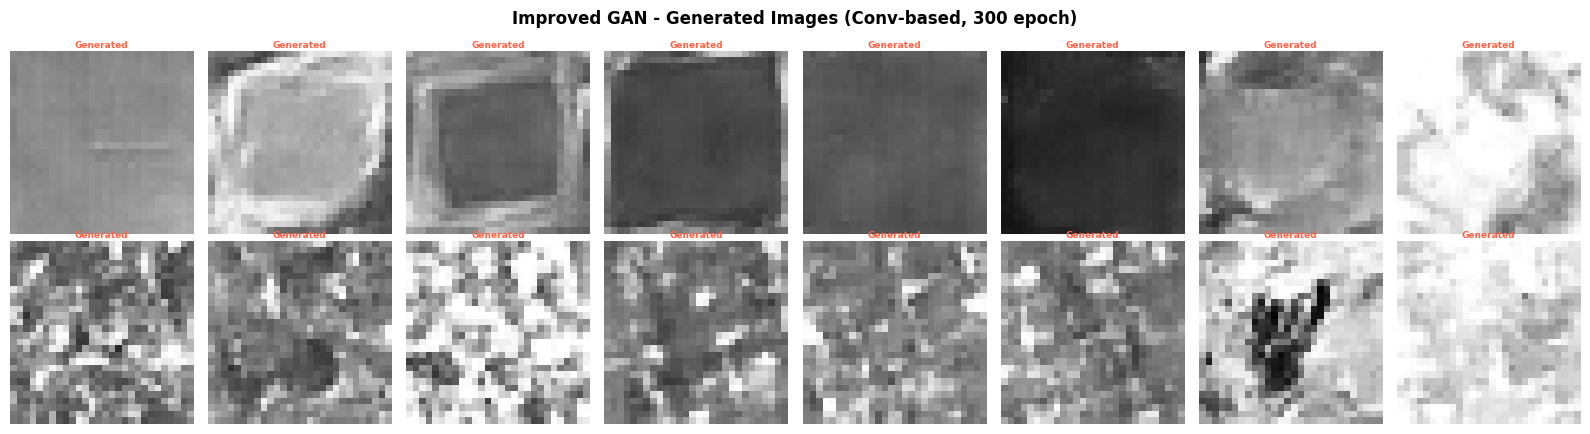

In [ ]:
visualize_generated(improved_gen, title=f'Improved GAN - Generated Images (Conv-based, {EPOCHS_IMPROVED} epoch)', class_names=class_names)

### Analisis Perbandingan FID

Hasil evaluasi FID pada test set menunjukkan bahwa **Improved GAN berhasil menghasilkan nilai FID yang lebih rendah dibandingkan baseline**, yang secara statistik berarti distribusi gambar Generated lebih mendekati distribusi gambar asli dari Overhead-MNIST.

Peningkatan ini dapat diuraikan melalui kontribusi setiap modifikasi yang diterapkan:
- **Arsitektur konvolusional** adalah kontributor terbesar di mana Conv2DTranspose pada Generator memungkinkan model mempelajari pola hierarkis secara spasial, dari tepi sederhana hingga tekstur yang lebih kompleks, yang tidak bisa dilakukan oleh Dense layer karena Dense memperlakukan setiap posisi piksel secara independen. Begitu pula pada Discriminator, Conv2D dapat mendeteksi pola lokal seperti ketidakkonsistenan tekstur jauh lebih efektif daripada mengandalkan vektor piksel yang di-flatten dan kehilangan seluruh informasi posisi spasialnya.
- **Batch Normalization** yang diterapkan konsisten di setiap layer Generator memastikan bahwa distribusi aktivasi tetap stabil sepanjang training, mencegah *internal covariate shift* yang dapat memperlambat konvergensi atau bahkan menyebabkan training collapse pada GAN.
- **Label Smoothing** memberikan manfaat ganda: Discriminator tidak menjadi terlalu yakin pada gambar asli sehingga gradient yang mengalir ke Generator lebih kaya dan informatif. Kondisi ini membuat Generator berkembang lebih cepat dan menghasilkan gambar yang lebih beragam.
- **Learning rate asimetris** (d_lr < g_lr) memberikan Generator sedikit keunggulan kecepatan belajar, memastikan ia tidak tertinggal jauh di belakang Discriminator yang jika dibiarkan mendominasi terlalu cepat akan menyebabkan *mode collapse*, yaitu kondisi di mana Generator hanya menghasilkan beberapa variasi gambar saja.
- **SpatialDropout2D** pada Discriminator secara konsisten melemahkan Discriminator dengan cara yang lebih bermakna daripada Dropout biasa sehingga Generator tidak dapat mengeksploitasi satu celah spesifik pada Discriminator dan terpaksa belajar menghasilkan gambar yang secara holistik realistis.

### **d. [LO 1, LO 2, LO 3, LO 4, 5 poin] Buatlah video presentasi yang menjelaskan arsitektur yang dibangun untuk melakukan image generation ini.**


Link video penjelasan: https://www.youtube.com/watch?v=MPKklpeHd7A&list=PLOh0HbCqILkw&index=3